In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc
import arviz as az
import pytensor.tensor as pt

import warnings
# warnings.filterwarnings('ignore')

In [2]:
def f_2(x):
  return 1 / (1 + pymc.math.exp(20 * (x - 0.2)))

def f_3(x):
    # term1 = 1 / (x * pymc.math.sqrt(3 * np.pi))
    # exponent = -0.5 * ((pymc.math.log(x) + pymc.math.sqrt(1.5) - pymc.math.log(3)) ** 2)
    # return term1 * pymc.math.exp(exponent)
    return (1-x)*(1-f_2(x)-f_5(x))

def f_4(x):
    return f_3(1 - x)

def f_5(x):
    return f_2(1 - x)

In [3]:
def create_bipartite_bayesian_network_vectorized(
    ratings_matrix,
    student_alpha=2, student_beta=2,
    item_alpha=2, item_beta=2,
    draws=1000, tune=1000, chains=2, cores=2
):
    n_students, n_items = ratings_matrix.shape

    obs_rows, obs_cols = np.where(~np.isnan(ratings_matrix))
    obs_ratings = ratings_matrix[obs_rows, obs_cols].astype(int)
    n_obs = len(obs_ratings)

    if n_obs == 0:
        raise ValueError("No observed ratings (all NaN).")
    
    obs_shifted = obs_ratings - 2

    with pymc.Model() as bipartite_model:
        # Latent variables (vectorized)
        student_ability = pymc.Beta("student_ability",
                                  alpha=student_alpha, beta=student_beta,
                                  shape=n_students)
        item_difficulty = pymc.Beta("item_difficulty",
                                  alpha=item_alpha, beta=item_beta,
                                  shape=n_items)
        
    
        a = student_ability[obs_rows]
        d = item_difficulty[obs_cols]
        ratio = (a / (a + d))

        eps = 1e-12
        ratio_clip = pt.clip(ratio, eps, 1 - eps)

        p2 = f_2(ratio_clip)
        p3 = f_3(ratio_clip)
        p4 = f_4(ratio_clip)
        p5 = f_5(ratio_clip)

        else_probs_raw = pt.stack([p2, p3, p4, p5], axis=1)
        else_probs = else_probs_raw / else_probs_raw.sum(axis=1, keepdims=True)

        const_5 = pt.as_tensor_variable([0.001, 0.001, 0.001, 0.997])
        const_2 = pt.as_tensor_variable([0.997, 0.001, 0.001, 0.001])


        p_const_5 = pt.ones((n_obs, 1)) * const_5
        p_const_2 = pt.ones((n_obs, 1)) * const_2
    
        cond_to_get_5 = a > (1.8 + d * 0.2)
        cond_to_get_2 = a < 0*(d * 0.2)

        cond_to_get_5_col = cond_to_get_5[:, None]
        cond_to_get_2_col = cond_to_get_2[:, None]

        prob_vec = pymc.math.switch(
            cond_to_get_5_col,
            p_const_5,
            pymc.math.switch(cond_to_get_2_col, p_const_2, else_probs)
        )

        pymc.Categorical("ratings_obs", p=prob_vec, observed=obs_shifted)

        trace = pymc.sample(
            draws=draws, tune=tune, chains=chains, cores=cores,
            target_accept=0.95, return_inferencedata=True, max_tree_depth=30
        )

    return trace, bipartite_model

In [4]:
def create_bipartite_bayesian_network_good(ratings_matrix, student_alpha=2, student_beta=2,
                                      item_alpha=2, item_beta=2,
                                      draws=1000, tune=1000, chains=2, cores=2):
  n_students, n_items = ratings_matrix.shape

  with pymc.Model() as bipartite_model:

        student_ability = [pymc.Beta(
            f"student_ability_{i}",
            alpha=student_alpha,
            beta=student_beta
        ) for i in range(n_students)]

        item_difficulty = [pymc.Beta(
            f'item_difficulty_{i}',
            alpha=item_alpha,
            beta=item_beta
        ) for i in range(n_items)]

        mark = [[0 for i in range(n_items)] for j in range(n_students)]

        for student in range(n_students):
          for subject in range(n_items):
            if ratings_matrix[student][subject] is np.nan: continue
            observed = ratings_matrix[student][subject] - 2
            ratio = student_ability[student]/(student_ability[student]+item_difficulty[subject])
            probabilities = [f_2(ratio),f_3(ratio),f_4(ratio),f_5(ratio)]
            probabilities_norm = [i/sum(probabilities) for i in probabilities]
            mark[student][subject] = pymc.Categorical(f'mark{student}_{subject}',probabilities_norm,observed=ratings_matrix[student][subject]-2)

        # 6. Сэмплирование
        trace = pymc.sample(
            draws=draws,
            tune=tune,
            chains=chains,
            cores=cores,
            target_accept=0.9,
            return_inferencedata=True
        )

  return trace, bipartite_model

In [5]:
def generate_data(students_size, items_size, random_state=42):
    np.random.seed(random_state)
    return np.random.randint(low=2, high=5, size=students_size * items_size).reshape(students_size, items_size)

In [6]:
data = generate_data(4, 3)

trace, model = create_bipartite_bayesian_network_vectorized(
    ratings_matrix=data,
    student_alpha=2,
    student_beta=2,
    item_alpha=2,
    item_beta=4,
    draws=1000,
    tune=2000,
    chains=6,
    cores=6
)

c:\Users\user\anaconda3\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (6 chains in 6 jobs)
NUTS: [student_ability, item_difficulty]


c:\Users\user\anaconda3\envs\pymc_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 6 chains for 2_000 tune and 1_000 draw iterations (12_000 + 6_000 draws total) took 30 seconds.


In [11]:
def show_trace(trace):
    fig, axes = plt.subplots(ncols=2, nrows=7, figsize=(14, 20))

    az.plot_trace(trace,
                compact=False,
                legend=True,
                axes=axes)
    plt.tight_layout()
    plt.show()
    

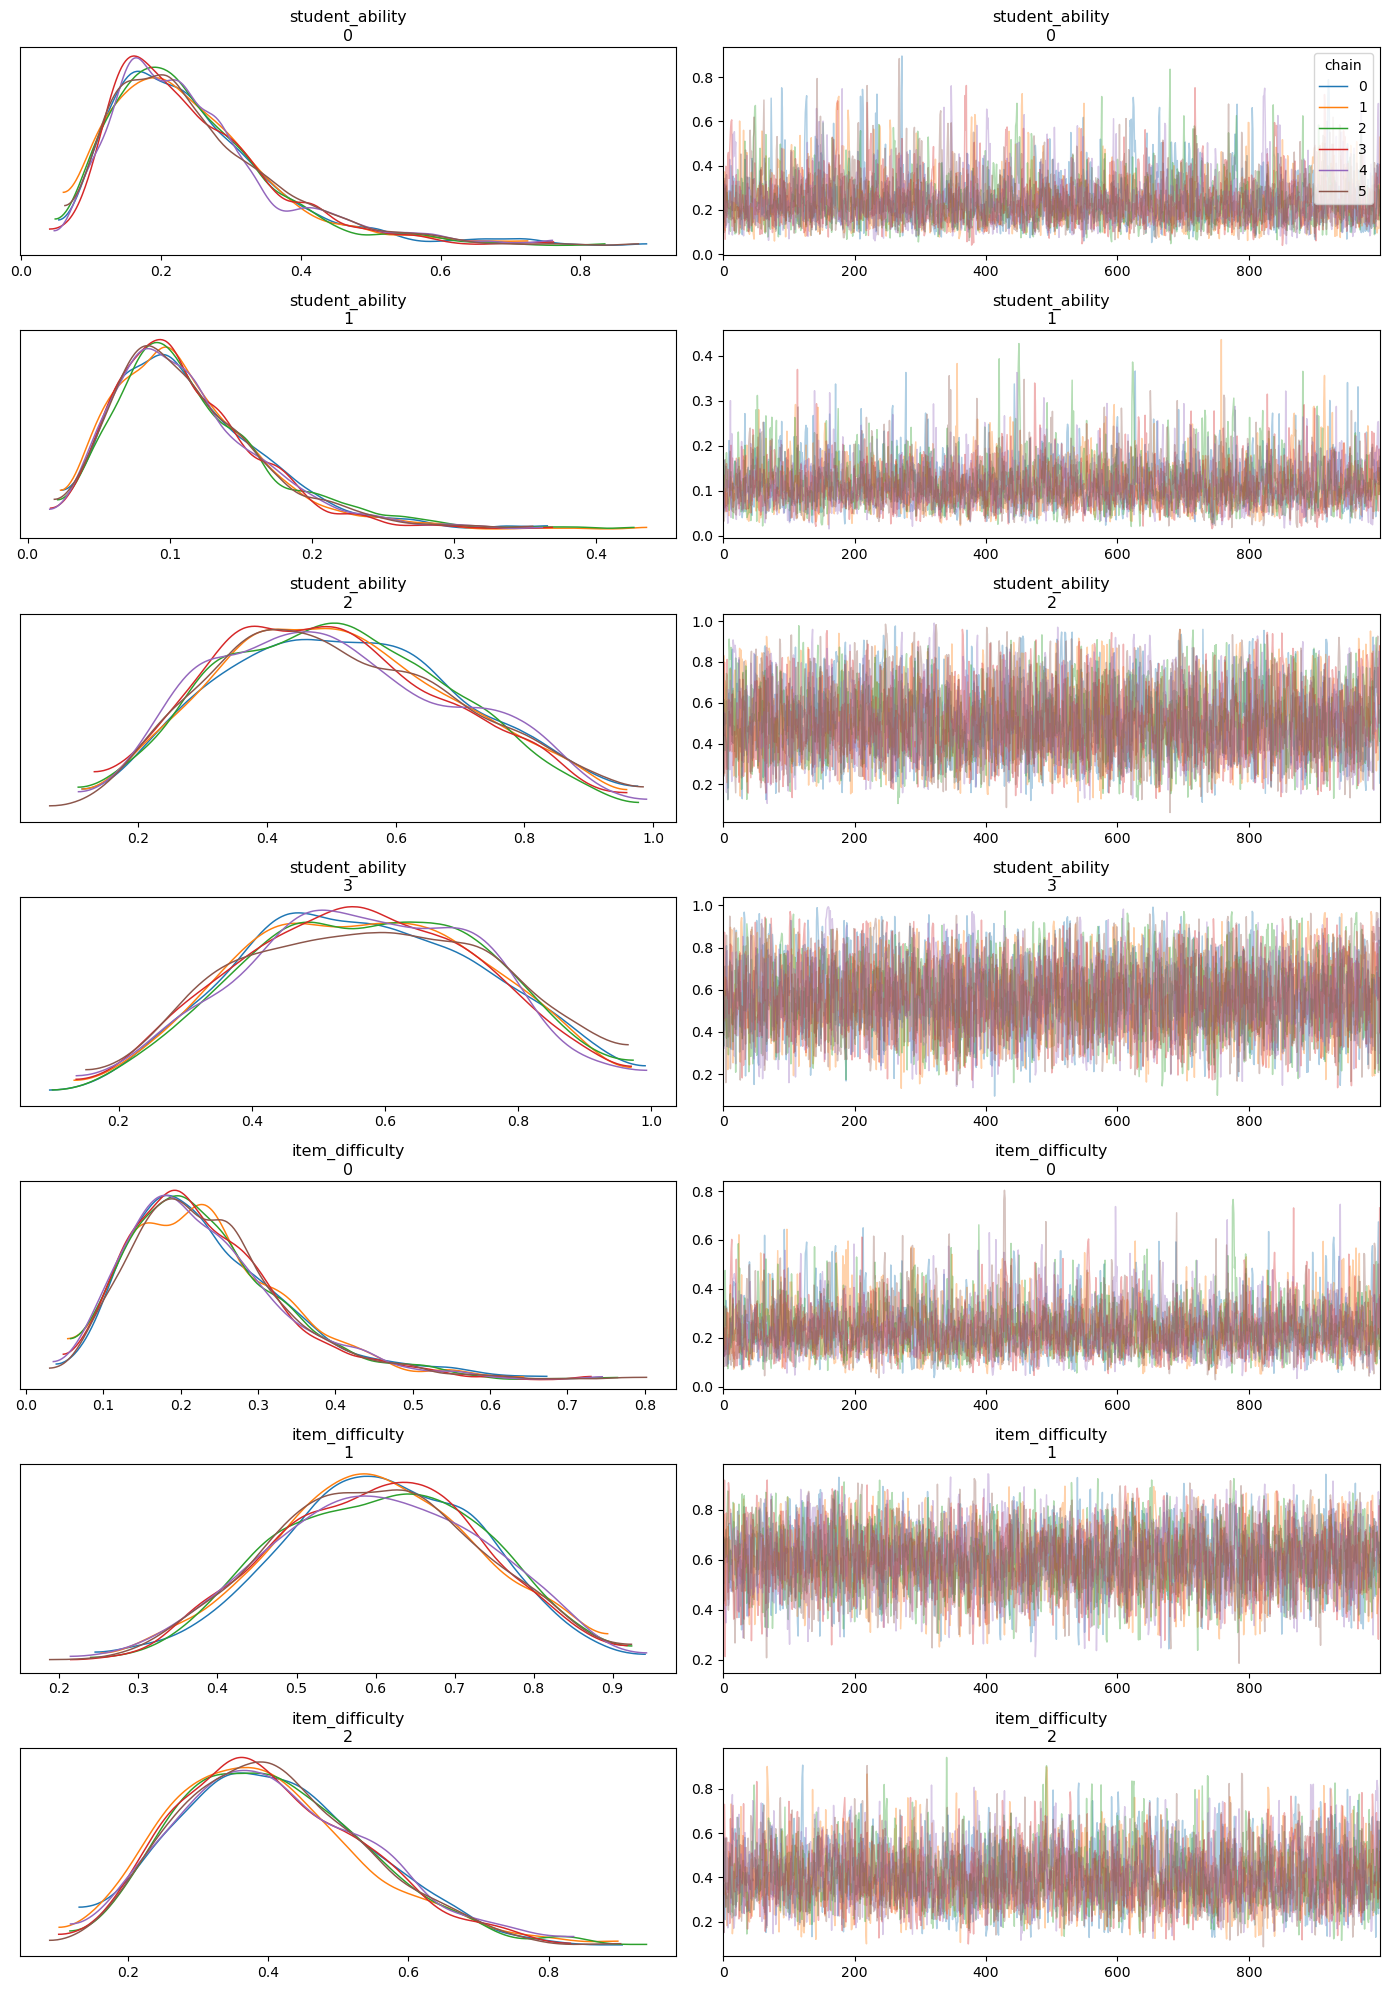

In [12]:
show_trace(trace)